# Tutorial: Understanding CNNs Through a Single Astronaut Image  
## Visualising Filters and Feature Maps with Keras and `scikit-image`

## Introduction
Many CNN tutorials focus on classification accuracy. This one focuses on **interpretability**: what a convolutional neural network *learns* and how those internal representations change from layer to layer. We use a single built-in cat image from `scikit-image` so the notebook is easy to run and easy to understand.

### Learning goals
By the end of this tutorial, you should be able to:

1. explain how convolutions and feature maps work,
2. load and preprocess an image for a Keras CNN,
3. inspect learned filters from an early convolutional layer,
4. visualise feature maps from shallow and deeper layers,
5. critically evaluate what these visualisations do and do not tell us.

### Accessibility notes

This notebook includes several accessibility choices:

- each figure is introduced and explained in text,
- plots use colour-blind friendly greyscale,
- headings are screen-reader friendly and follow a logical order,
- code is split into small, runnable sections,
- observations are written out instead of being left implicit in images alone.

## 1. Background: What does a CNN learn?

A convolutional neural network (CNN) is designed to automatically learn useful features from images. Instead of relying on manually engineered features, CNNs learn directly from data by applying small filters across an image (Goodfellow, Bengio and Courville, 2016).

Each filter responds strongly to specific local patterns. In early layers, these patterns are simple—such as edges, colour transitions, or basic textures. As the network becomes deeper, it combines these simple patterns into more complex structures like textures, object parts (e.g. eyes or fur), and eventually full semantic representations (Chollet, 2018; Goodfellow, Bengio and Courville, 2016).

This process is known as **hierarchical representation learning**:

- **Early layers** detect simple local features (edges, colours)  
- **Middle layers** combine these into textures and patterns  
- **Deeper layers** capture object parts and high-level meaning (Goodfellow, Bengio and Courville, 2016)

---

## 2. What is a Convolution?

A convolution is the core mathematical operation behind CNNs (Goodfellow, Bengio and Courville, 2016). It involves applying a small matrix of learnable parameters—called a **filter** or **kernel**—across an image.

Typically, filters are small (e.g. 3×3 or 5×5). As the filter slides across the image, it computes a weighted sum of the input pixels at each position. This operation produces a new image-like output called a **feature map**.

Each filter becomes specialised to detect a particular visual pattern, such as:

- Horizontal edges  
- Vertical edges  
- Colour transitions  
- Diagonal gradients  

For example, a simple horizontal edge detector can be represented as:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
1 & 1 & 1
\end{bmatrix}
$$

When this kernel is applied to an image, it produces high values in regions where horizontal edges are present.

---

## 3. How CNNs Work

A CNN processes images through a sequence of layers, each transforming the data into more abstract representations.

### Key Components

1. **Convolutional Layers**  
   - Apply filters across the image  
   - Extract features such as edges, textures, and shapes  

2. **Activation Functions (ReLU)**  
   - Introduce non-linearity  
   - Enable the network to learn complex patterns  

3. **Pooling Layers**  
   - Reduce spatial dimensions  
   - Retain the most important information  

4. **Fully Connected Layers**  
   - Combine extracted features  
   - Perform final classification or prediction  




## 4. Why use a single image?

Using one image has two teaching advantages:

1. it removes the distraction of dataset management and training loops,
2. it lets us focus on how the same visual input is transformed across layers.

We use **Astronaut**, a built-in image from `scikit-image`, which makes the notebook reproducible without downloading external files.

In [2]:
# If needed, uncomment and run:
# !pip install tensorflow scikit-image matplotlib

import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model


## 5. Load and preprocess the image

Keras application models expect images in a specific size and pixel format.  
We will:

1. load the Chelsea cat image,
2. resize it to `224 x 224`,
3. convert it into a batch of one image,
4. apply the same preprocessing used for VGG16.

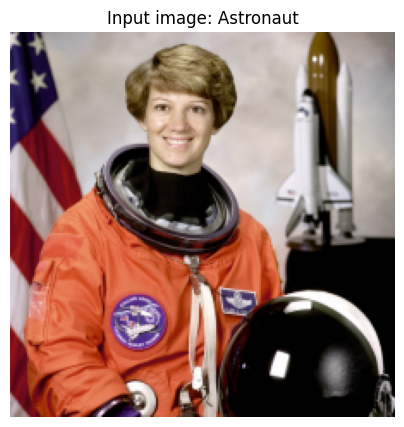

Image batch shape: (1, 224, 224, 3)


In [4]:
astro = data.astronaut() # you can also use other images (.cat, .rocket, .coffee)
astro_resized = resize(
    astro, (224, 224), anti_aliasing=True, preserve_range=True
).astype("float32")

x = np.expand_dims(astro_resized.copy(), axis=0)
x_preprocessed = preprocess_input(x.copy())

plt.figure(figsize=(5, 5))
plt.imshow(astro_resized.astype("uint8"))
plt.title("Input image: Astronaut")
plt.axis("off")
plt.show()

print("Image batch shape:", x_preprocessed.shape)


## 6. Load a Keras CNN

To make the visualisations meaningful, we use **VGG16 pretrained on ImageNet** (Simonyan and Zisserman, 2015).  
That gives us filters that have already learned useful visual patterns.

> Note: the first run may download pretrained weights. If internet access is unavailable, switch `weights="imagenet"` to `weights=None`. The notebook will still run, but the visualisations will be less informative because the filters will be untrained.

In [ ]:
model = VGG16(weights="imagenet", include_top=False)
model.summary()


## 7. Visualise filters from the first convolutional layer

Filters are the learned kernels that scan over the image.  
Early filters often respond to edges, gradients, and simple textures.

In [ ]:
# First convolutional layer in VGG16 after the InputLayer
filters, biases = model.layers[1].get_weights()
print("Filter tensor shape:", filters.shape)  # (3, 3, 3, 64)

# Normalise filter values to 0-1 for visualisation
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)


In [ ]:
n_filters = 6

plt.figure(figsize=(10, 10))
for i in range(n_filters):
    f = filters_norm[:, :, :, i]
    for j in range(3):  # RGB channels
        ax = plt.subplot(n_filters, 3, i * 3 + j + 1)
        ax.imshow(f[:, :, j], cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f"Channel {j+1}")
plt.suptitle("First 6 learned filters from the first convolutional layer\n")
plt.tight_layout()
plt.show()

## 8. Build a model that returns intermediate activations

A **feature map** is the output produced when a filter is applied to an image.  
To study the internal representation, we create a new model that returns the activations of selected layers.

In [ ]:
layer_outputs = [layer.output for layer in model.layers]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

activations = activation_model.predict(x_preprocessed)

layer_names = [layer.name for layer in model.layers]

for i, name in enumerate(layer_names):
    print(i, name)


In [ ]:
activations = activation_model.predict(x_preprocessed)
print(f"Collected {len(activations)} activation tensors.")
for name, act in zip(layer_names, activations):
    print(f"{name:15s} -> {act.shape}")


In [ ]:
def show_feature_maps(feature_tensor, n=16, title=""):
    plt.figure(figsize=(10, 10))
    for i in range(min(n, feature_tensor.shape[-1])):
        ax = plt.subplot(4, 4, i + 1)
        ax.imshow(feature_tensor[0, :, :, i], cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Map {i+1}", fontsize=9)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## 9. Visualise feature maps from the first convolutional layer

Feature maps show the output after filters are applied to the image.

In [ ]:
first_layer_activation = activations[1]  # block1_conv1 output
print(first_layer_activation.shape)


In [ ]:
show_feature_maps(
    first_layer_activation,
    n=16,
    title="First 16 feature maps from block1_conv1",
)


## 10. Visualise feature maps from shallow to deeper layers

As layers get deeper:

- spatial detail usually decreases
- semantic abstraction usually increases
- activations become harder for humans to interpret directly


In [ ]:
conv_indices = [1, 2, 4, 5, 7, 8]  # convolutional layers 1 and 2 from block 1, 2 and 3

for idx in conv_indices:
    act = activations[idx]
    name = layer_names[idx]
    show_feature_maps(act, n=16, title=f"First 16 feature maps from {name}")


### Reading these figures

As depth increases, three common trends often appear:

1. **Some channels become highly selective**, responding strongly only to particular regions or structures,
2. **Spatial detail decreases** relative to the original image,
3. **Representations become less human-interpretable**, even though they may become more useful for the model.

In the earliest layers, you can often still recognise edges, contours, and strong intensity boundaries in the astronaut image, such as the outline of the helmet, facial features, and high-contrast transitions.
In deeper layers, channels begin to emphasise more abstract structure, such as face regions, helmet components, clothing patterns, and other salient object parts, rather than directly visible pixel-level details.



## 11. Compare one shallow layer with one deeper layer

The next figure makes that contrast more explicit by comparing a few channels from an early layer and a deeper layer.


In [ ]:
shallow = activations[1]   # block1_conv1
deep = activations[11]      # block4_conv1

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    axes[0, i].imshow(shallow[0, :, :, i], cmap="gray")
    axes[0, i].set_title(f"Shallow ch {i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(deep[0, :, :, i], cmap="gray")
    axes[1, i].set_title(f"Deeper ch {i+1}")
    axes[1, i].axis("off")

plt.suptitle("Shallow (block1_conv1) vs deeper (block4_conv1) feature maps", fontsize=14)
plt.tight_layout()
plt.show()


### Critical comparison

The shallow maps usually preserve more visible edges and local image structure.  
The deeper maps are harder for a human to decode directly, which is an important lesson: **useful representation learning does not always produce human-friendly pictures**.

That is one reason interpretability in deep learning is difficult. Visualisation helps, but it is never the full story.

## 12. Ethical and practical relevance

Interpretability matters beyond curiosity.

- In safety-critical systems, understanding model behaviour can help detect failure modes.
- In applied machine learning, feature visualisation can support debugging and model selection.
- In ethical AI, interpretability tools may help identify spurious correlations, though they are not sufficient on their own.

A responsible practitioner should treat visual explanations as **evidence**, not as unquestionable proof.

## 13. Reflection questions

1. Which early feature maps seem to emphasise edges most strongly?
2. In the deeper layer, which channels seem to focus on the cat's face or fur?
3. Why are deeper feature maps often harder for humans to interpret?
4. Why might filter visualisation alone be insufficient for explaining a prediction?
5. What changes if you replace the cat image with your own image?

## 14. Conclusion

This tutorial used a single image to show how a pretrained Keras CNN transforms visual information across layers.  
That narrow focus is a strength: it makes the interpretability story clearer.

The main takeaway is that CNNs do not "see" an image all at once. They build understanding progressively:

- from edges,
- to textures and motifs,
- to increasingly abstract internal representations.

That layered transformation is one of the central reasons CNNs are so effective in computer vision.

## 13. References

- Chollet, F. (2018) Deep Learning with Python. Manning.
- Goodfellow, I., Bengio, Y. and Courville, A. (2016) Deep Learning. MIT Press.
- Simonyan, K. and Zisserman, A. (2015) Very Deep Convolutional Networks for Large-Scale Image Recognition.
- Zeiler, M.D. and Fergus, R. (2014) Visualizing and Understanding Convolutional Networks.